# 1 - Imports

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0].parents[0]))

In [4]:
from src.utils import config, io
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


In [5]:
import mlflow
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2 - Preprocessing

In [8]:
def expanding_window_split(df, start_year, end_year, val_start_year):

    for val_year in range(val_start_year, end_year + 1):
        
        train_mask = (df['YEAR'] >= start_year) & (df['YEAR'] < val_year)
        val_mask = df['YEAR'] == val_year
        
        train_idx = df.index[train_mask]
        val_idx = df.index[val_mask]
        
        if len(val_idx) > 0:
            yield train_idx, val_idx


# 3 - Parameter Tuning Logistic Regression

## 3.1 - Run Parameters Cross Validation

In [10]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
# mlflow.create_experiment('LR Model Parameters')
mlflow.set_experiment('LR Model Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/634986757284139096', creation_time=1771078522076, experiment_id='634986757284139096', last_update_time=1771078522076, lifecycle_stage='active', name='LR Model Parameters', tags={}>

In [11]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

In [12]:
preprocessor_params = {
    'num_imputer': 'uni',
    'num_imputer_uni_strategy': 'most_frequent',
    'cat_imputer': 'uni',
    'cat_imputer_uni_strategy': 'most_frequent'
}
preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params)

In [13]:
import numpy as np
np.logspace(-4,2, 7),

(array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]),)

In [14]:
model_params_grid = { 
    'penalty': ['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4, 1, 6),
    'solver': ['lbfgs','newton-cg','liblinear','sag'],
    'max_iter'  : [500, 1000, 2500],
}

In [15]:
i = 0
for penalty, C_v, solver, max_iter,  in product( # solver, class_weight
    model_params_grid['penalty'],
    model_params_grid['C'],
    model_params_grid['solver'],
    model_params_grid['max_iter'],
):

    i += 1
    if i%50 == 0:
        print('Progress', str(round(100*i/(np.prod([len(vs) for vs in model_params_grid.items()])), 1)), '%')

    model_params = {
        'penalty': penalty,
        'C': C_v,
        'solver': solver,
        'max_iter': max_iter
    }

    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    with mlflow.start_run():
        correct = True
        for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
            fold_prefix = 'fold_' + str(fold) + '_'
            
            X_train, y_train = X.loc[train_idx], y.loc[train_idx, 'OECD_RATING']
            X_val, y_val = X.loc[val_idx], y.loc[val_idx, 'OECD_RATING']
            
            model = model_pipeline.get_model_pipeline('logistic_regression', preprocessor, model_params)

            try:
                model.fit(X_train, y_train)
            except ValueError:
                print('Error with Params:', model_params)
                correct = False
                break

            val_fold_results = evaluate.evaluate_model(model, X_val, y_val, prefix=fold_prefix, verbose=False)

            cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
            cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
            cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
            cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

        
        mlflow.log_params(model_params)
        
        if fold == 0:
            cv_mean_scores = {'cv_mean_' + k: 0.0 for k, vs in cv_scores.items()}
        else:
            cv_mean_scores = {'cv_mean_' + k: np.mean(vs) for k, vs in cv_scores.items()}
            print(model_params)
            print(cv_mean_scores)
        mlflow.log_metrics(cv_mean_scores)

Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 500}
Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 1000}
Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 2500}
Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 500}
Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 1000}
Error with Params: {'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 2500}
{'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'liblinear', 'max_iter': 500}
{'cv_mean_accuracy': np.float64(0.3163895264451335), 'cv_mean_precision': np.float64(0.3163895264451335), 'cv_mean_recall': np.float64(0.14285714285714282), 'cv_mean_f1': np.float64(0.06866788017485347)}
{'penalty': 'l1', 'C': np.float64(0.0001), 'solver': 'liblinear', 'max_iter': 1000}
{'cv_mean_accuracy': np.f

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'penalty': 'l2', 'C': np.float64(0.1), 'solver': 'sag', 'max_iter': 500}
{'cv_mean_accuracy': np.float64(0.6787399219048895), 'cv_mean_precision': np.float64(0.6384529094892194), 'cv_mean_recall': np.float64(0.5843745492754934), 'cv_mean_f1': np.float64(0.5810658511059634)}
{'penalty': 'l2', 'C': np.float64(0.1), 'solver': 'sag', 'max_iter': 1000}
{'cv_mean_accuracy': np.float64(0.6787399219048895), 'cv_mean_precision': np.float64(0.6384529094892194), 'cv_mean_recall': np.float64(0.5843745492754934), 'cv_mean_f1': np.float64(0.5810658511059634)}
{'penalty': 'l2', 'C': np.float64(0.1), 'solver': 'sag', 'max_iter': 2500}
{'cv_mean_accuracy': np.float64(0.6787399219048895), 'cv_mean_precision': np.float64(0.6384529094892194), 'cv_mean_recall': np.float64(0.5843745492754934), 'cv_mean_f1': np.float64(0.5810658511059634)}
{'penalty': 'l2', 'C': np.float64(1.0), 'solver': 'lbfgs', 'max_iter': 500}
{'cv_mean_accuracy': np.float64(0.718527802390175), 'cv_mean_precision': np.float64(0.68827000

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/li

{'penalty': 'l2', 'C': np.float64(1.0), 'solver': 'sag', 'max_iter': 500}
{'cv_mean_accuracy': np.float64(0.7105547924940881), 'cv_mean_precision': np.float64(0.6814501555044608), 'cv_mean_recall': np.float64(0.6292715064970504), 'cv_mean_f1': np.float64(0.6350831289636188)}


...

{'penalty': 'l2', 'C': np.float64(10.0), 'solver': 'sag', 'max_iter': 500}
{'cv_mean_accuracy': np.float64(0.7185697450525995), 'cv_mean_precision': np.float64(0.679132113749885), 'cv_mean_recall': np.float64(0.6349633351825105), 'cv_mean_f1': np.float64(0.6425687988669738)}


/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/li

{'penalty': 'l2', 'C': np.float64(10.0), 'solver': 'sag', 'max_iter': 1000}
{'cv_mean_accuracy': np.float64(0.7276187089092557), 'cv_mean_precision': np.float64(0.687831474521967), 'cv_mean_recall': np.float64(0.6531072607010852), 'cv_mean_f1': np.float64(0.6599848010802734)}


/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/sklearn/li

{'penalty': 'l2', 'C': np.float64(10.0), 'solver': 'sag', 'max_iter': 2500}
{'cv_mean_accuracy': np.float64(0.7346357303493539), 'cv_mean_precision': np.float64(0.7063430303913768), 'cv_mean_recall': np.float64(0.6685207704119827), 'cv_mean_f1': np.float64(0.6765550652196657)}
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 500}
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 1000}
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'lbfgs', 'max_iter': 2500}
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 500}
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 1000}
Progress 1875.0 %
Error with Params: {'penalty': 'elasticnet', 'C': np.float64(0.0001), 'solver': 'newton-cg', 'max_iter': 2500}
Error with Params: {'penalty': 'elasticnet', 'C': np

## 3.2 - Analysis

In [20]:
e = mlflow.set_experiment('LR Model Parameters')
e.experiment_id

'634986757284139096'

In [21]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

996

In [22]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)


In [42]:
run.info.status

'FAILED'

In [57]:
df = pd.DataFrame(rows)
# df = df.astype(float)
df = df.dropna(subset=['cv_mean_f1'])
df = df[df['cv_mean_f1'] > 0.0]
num_cols = ['max_iter', 'C', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy', 'cv_mean_recall']
df.loc[:, num_cols] = df[num_cols].astype(float)
df = df.drop_duplicates()
df

,penalty,solver,max_iter,C,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
144,l2,sag,2500.0,10.0,0.706343,0.676555,0.734636,0.668521
145,l2,sag,1000.0,10.0,0.687831,0.659985,0.727619,0.653107
146,l2,sag,500.0,10.0,0.679132,0.642569,0.718570,0.634963
147,l2,liblinear,2500.0,10.0,0.668706,0.630724,0.704549,0.622412
148,l2,liblinear,1000.0,10.0,0.668706,0.630724,0.704549,0.622412
...,...,...,...,...,...,...,...,...
877,l1,saga,100.0,2.782559,0.641408,0.583058,0.678722,0.585689
897,l1,saga,100.0,0.359381,0.639998,0.573177,0.673654,0.574928
917,l1,saga,100.0,0.046416,0.633659,0.502268,0.626700,0.511896
925,l1,liblinear,100.0,0.046416,0.588195,0.452730,0.592854,0.468260


In [58]:
df.sort_values(by=['cv_mean_f1'], ascending=False).head(20)

,penalty,solver,max_iter,C,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
489,l1,saga,5000.0,21.544347,0.703228,0.676980,0.735646,0.672534
144,l2,sag,2500.0,10.0,0.706343,0.676555,0.734636,0.668521
151,l2,newton-cg,1000.0,10.0,0.704128,0.676047,0.736584,0.669211
152,l2,newton-cg,500.0,10.0,0.704128,0.676047,0.736584,0.669211
150,l2,newton-cg,2500.0,10.0,0.704128,0.676047,0.736584,0.669211
154,l2,lbfgs,1000.0,10.0,0.697243,0.671033,0.733637,0.666354
153,l2,lbfgs,2500.0,10.0,0.697243,0.671033,0.733637,0.666354
155,l2,lbfgs,500.0,10.0,0.697243,0.671033,0.733637,0.666354
490,l1,saga,2500.0,21.544347,0.695150,0.669506,0.730619,0.663511
509,l1,saga,5000.0,2.782559,0.694660,0.663968,0.734618,0.656523


### 3.2.1 Per Parameter Analysis

In [46]:
model_params_grid = { 
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C' : np.logspace(-4, 1, 6),
    'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag'],
    'max_iter'  : [500, 1000, 2500],
}

#### Penalty 

In [59]:
df['penalty'].value_counts()

penalty
l1    99
l2    72
Name: count, dtype: int64

Text(0, 0.5, 'Mean F1 Score')

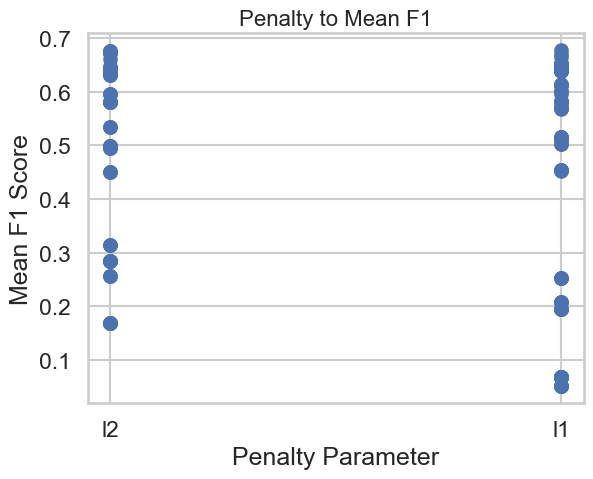

In [60]:
plt.scatter(df['penalty'], df['cv_mean_f1'])
plt.title('Penalty to Mean F1', fontsize=16)
plt.xlabel('Penalty Parameter')
plt.ylabel('Mean F1 Score')

#### C

Text(0, 0.5, 'Mean F1 Score')

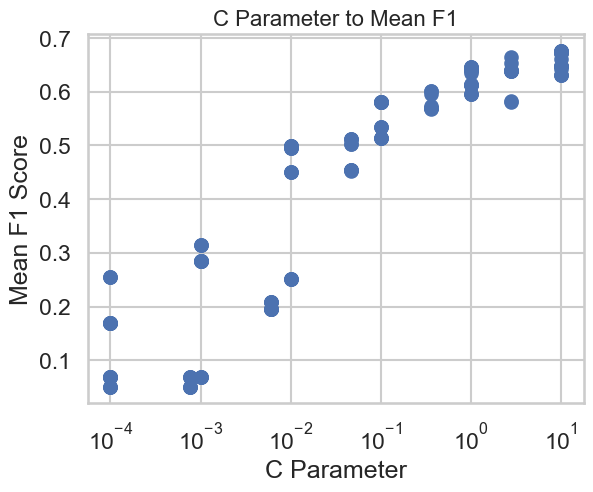

In [61]:
df_subset = df[df['C'].astype(float) <= 10.0]
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['C'], df_subset['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('C Parameter to Mean F1', fontsize=16)
ax.set_xlabel('C Parameter')
ax.set_ylabel('Mean F1 Score')


#### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

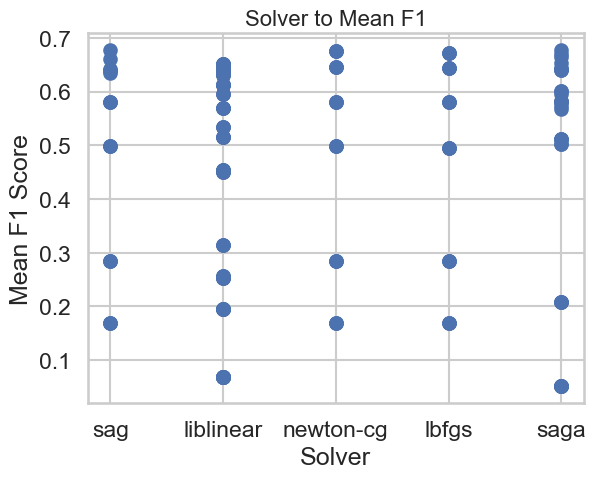

In [62]:
plt.scatter(df['solver'], df['cv_mean_f1'])
plt.title('Solver to Mean F1', fontsize=16)
plt.xlabel('Solver')
plt.ylabel('Mean F1 Score')

#### Max Iteration

Text(0, 0.5, 'Mean F1')

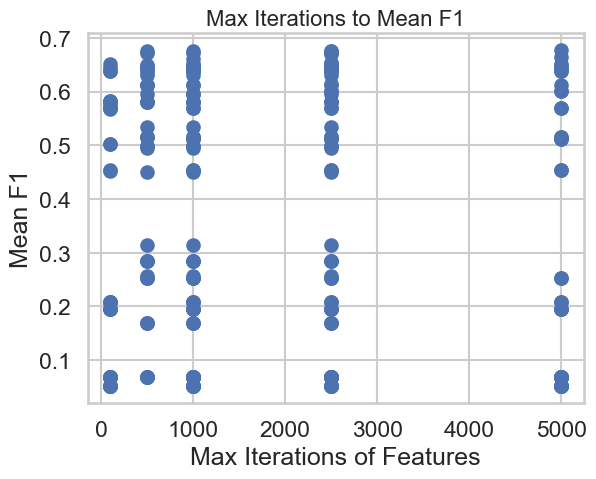

In [52]:
plt.scatter(df['max_iter'], df['cv_mean_f1'])
plt.title('Max Iterations to Mean F1', fontsize=16)
plt.xlabel('Max Iterations of Features')
plt.ylabel('Mean F1')

# 4 - Conclusion

In [ ]:
model_params = { 
    'penalty': 'l2',
    'C' : 10,
    'solver': 'newton-cg',
    'max_iter'  : 1000
}